# BPR Recommendation System Experiments

This notebook runs experiments using Bayesian Personalized Ranking (BPR) on LastFM and MovieLens datasets.

In [54]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

from joblib import Parallel, delayed
from implicit.bpr import BayesianPersonalizedRanking

In [55]:
# CONFIG
LASTFM_PATH = "hetrec2011-lastfm-2k/user_artists.dat"
MOVIELENS_PATH = "ml-1m/ratings.dat"
RANDOM_STATE = 42

In [77]:
# DATA LOADING
def load_lastfm(path):
    df = pd.read_csv(path, sep="\t")
    df = df.rename(columns={"userID": "user", "artistID": "item"})
    df["value"] = 1
    return df[["user", "item", "value"]]

def load_movielens(path):
    df = pd.read_csv(path, sep="::", engine="python", names=["user", "item", "rating", "timestamp"])
    df["value"] = 1
    return df[["user", "item", "value"]]

In [57]:
# SPLIT
def train_test_split_userwise(df, test_ratio=0.2):
    rng = np.random.default_rng(RANDOM_STATE)
    train_rows, test_rows = [], []

    for user, group in df.groupby("user"):
        if len(group) < 5:
            continue

        idx = np.arange(len(group))
        rng.shuffle(idx)
        split = int(len(group) * (1 - test_ratio))

        train_rows.append(group.iloc[idx[:split]])
        test_rows.append(group.iloc[idx[split:]])

    return pd.concat(train_rows), pd.concat(test_rows)

In [58]:
# MATRIX
def create_matrix(df):
    users = sorted(df.user.unique())
    items = sorted(df.item.unique())

    user_map = {u: i for i, u in enumerate(users)}
    item_map = {i: j for j, i in enumerate(items)}

    rows = df.user.map(user_map)
    cols = df.item.map(item_map)

    mat = sp.csr_matrix(
        (np.ones(len(df)), (rows, cols)),
        shape=(len(users), len(items))
    )

    return mat, user_map, item_map

In [59]:
# TEST DICT
def build_test_dict(test_df, user_map, item_map):
    test_dict = {}
    for user, group in test_df.groupby("user"):
        if user not in user_map:
            continue

        uid = user_map[user]
        items = {item_map[i] for i in group.item if i in item_map}
        test_dict[uid] = items

    return test_dict

In [60]:
# METRICS
def precision_recall_at_k(model, train_matrix, test_dict, k):
    precisions, recalls = [], []

    for user in test_dict:
        relevant = test_dict[user]
        if len(relevant) == 0:
            continue

        recs, _ = model.recommend(
            userid=user,
            user_items=train_matrix[user],
            N=k,
            filter_already_liked_items=True
        )

        recs = set(recs)
        hits = len(recs & relevant)

        precisions.append(hits / k)
        recalls.append(hits / len(relevant))

    return np.mean(precisions), np.mean(recalls)

In [61]:
# PARALLEL CORE
def single_run(model_fn, train_matrix, test_dict, k):
    model = model_fn()
    train_matrix_local = train_matrix.copy()
    model.fit(train_matrix_local)
    return precision_recall_at_k(model, train_matrix_local, test_dict, k)

def parallel_evaluate(model_fn, train_matrix, test_dict, k, n_runs=10, n_jobs=-1):
    results = Parallel(n_jobs=n_jobs, backend="threading", verbose=0)(
        delayed(single_run)(model_fn, train_matrix, test_dict, k)
        for _ in range(n_runs)
    )

    p = np.array([r[0] for r in results])
    r = np.array([r[1] for r in results])

    return p, r

def evaluate_mean_std(model_fn, train_matrix, test_dict, k, n_runs=10, n_jobs=-1):
    p, r = parallel_evaluate(model_fn, train_matrix, test_dict, k, n_runs, n_jobs)
    return np.mean(p), np.std(p), np.mean(r), np.std(r)

In [62]:
# PLOTTING
def plot_mean_std(x, mean, std, xlabel, ylabel, title, filename):
    mean = np.array(mean)
    std = np.array(std)

    plt.figure(figsize=(8,5))
    plt.plot(x, mean, marker='o', label="Mean")
    plt.fill_between(x, mean-std, mean+std, alpha=0.2, label="Std Dev")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.legend()
    plt.show()

In [68]:
def experiment_factors(train_matrix, test_dict, n_runs=10, n_jobs=-1):

    factors_range = list(range(10, 101, 10))

    p_mean, p_std = [], []
    r_mean, r_std = [], []

    ss = []

    for f in factors_range:

        model_fn = lambda: BayesianPersonalizedRanking(
            factors=f,
            learning_rate=0.01,
            regularization=0.01,
            iterations=100,
            random_state=None
        )

        pm, ps, rm, rs = evaluate_mean_std(
            model_fn,
            train_matrix,
            test_dict,
            k=10,
            n_runs=n_runs,
            n_jobs=n_jobs
        )

        p_mean.append(pm)
        p_std.append(ps)
        r_mean.append(rm)
        r_std.append(rs)

        s = f"F={f} | P={pm:.4f}±{ps:.4f} | R={rm:.4f}±{rs:.4f}"
        print(s)
        ss.append(s)

    for s in ss:
        print(s)

    return factors_range, p_mean, p_std, r_mean, r_std


def experiment_k(train_matrix, test_dict, n_runs=10, n_jobs=-1):

    ks = list(range(2, 21, 2))

    base_model = BayesianPersonalizedRanking(
        factors=50,
        learning_rate=0.01,
        regularization=0.01,
        iterations=100,
        random_state=None,
        # dont print progress for each run since we do multiple runs (handled in parallel_evaluate)
        # verbose=False
    )

    base_model.fit(train_matrix)

    p_mean, p_std = [], []
    r_mean, r_std = [], []

    ss = []

    for k in ks:

        model_fn = lambda: base_model

        pm, ps, rm, rs = evaluate_mean_std(
            model_fn,
            train_matrix,
            test_dict,
            k,
            n_runs=n_runs,
            n_jobs=n_jobs
        )

        p_mean.append(pm)
        p_std.append(ps)
        r_mean.append(rm)
        r_std.append(rs)

        s = f"K={k} | P={pm:.4f}±{ps:.4f} | R={rm:.4f}±{rs:.4f}"
        print(s)
        ss.append(s)

    for s in ss:
        print(s)

    return ks, p_mean, p_std, r_mean, r_std

In [64]:
print("Loading LastFM...")
lastfm = load_lastfm(LASTFM_PATH)

print("Loading MovieLens...")
movielens = load_movielens(MOVIELENS_PATH)

Loading LastFM...
Loading MovieLens...


In [65]:
print("\n====================")
print("Running experiments on LastFM")
print("====================")

train_df, test_df = train_test_split_userwise(lastfm)
full_df = pd.concat([train_df, test_df])

matrix, user_map, item_map = create_matrix(full_df)

train_rows = train_df.user.map(user_map)
train_cols = train_df.item.map(item_map)

train_matrix = sp.csr_matrix(
    (np.ones(len(train_df)), (train_rows, train_cols)),
    shape=matrix.shape
)

test_dict = build_test_dict(test_df, user_map, item_map)


Running experiments on LastFM


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

F=100 | P=0.1306±0.0019 | R=0.1323±0.0019
F=10 | P=0.1267±0.0020 | R=0.1283±0.0019
F=20 | P=0.1332±0.0018 | R=0.1350±0.0018
F=30 | P=0.1340±0.0017 | R=0.1358±0.0018
F=40 | P=0.1330±0.0017 | R=0.1347±0.0018
F=50 | P=0.1328±0.0024 | R=0.1346±0.0024
F=60 | P=0.1316±0.0019 | R=0.1333±0.0020
F=70 | P=0.1324±0.0017 | R=0.1342±0.0016
F=80 | P=0.1322±0.0028 | R=0.1339±0.0028
F=90 | P=0.1329±0.0018 | R=0.1345±0.0018
F=100 | P=0.1306±0.0019 | R=0.1323±0.0019


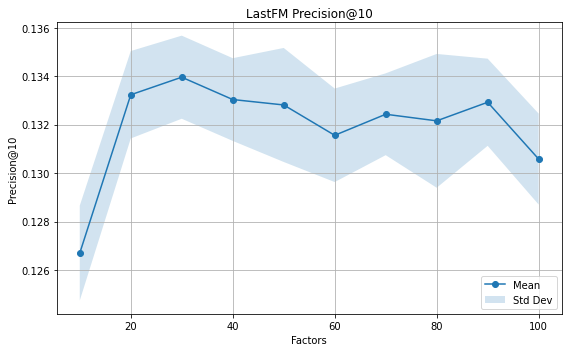

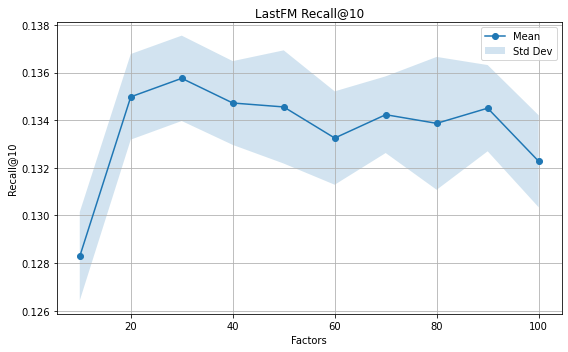

In [66]:
# ---------------- FACTORS ----------------
f, p, p_std, r, r_std = experiment_factors(train_matrix, test_dict)

plot_mean_std(f, p, p_std, "Factors", "Precision@10",
        f"LastFM Precision@10", f"LastFM_precision_factors.png")

plot_mean_std(f, r, r_std, "Factors", "Recall@10",
        f"LastFM Recall@10", f"LastFM_recall_factors.png")

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

K=20 | P=0.0913±0.0006 | R=0.1848±0.0011
K=2 | P=0.1721±0.0013 | R=0.0347±0.0003
K=4 | P=0.1494±0.0009 | R=0.0603±0.0004
K=6 | P=0.1349±0.0015 | R=0.0817±0.0010
K=8 | P=0.1247±0.0017 | R=0.1007±0.0013
K=10 | P=0.1162±0.0013 | R=0.1174±0.0013
K=12 | P=0.1105±0.0003 | R=0.1338±0.0003
K=14 | P=0.1041±0.0003 | R=0.1473±0.0004
K=16 | P=0.0991±0.0012 | R=0.1604±0.0020
K=18 | P=0.0946±0.0007 | R=0.1721±0.0014
K=20 | P=0.0913±0.0006 | R=0.1848±0.0011


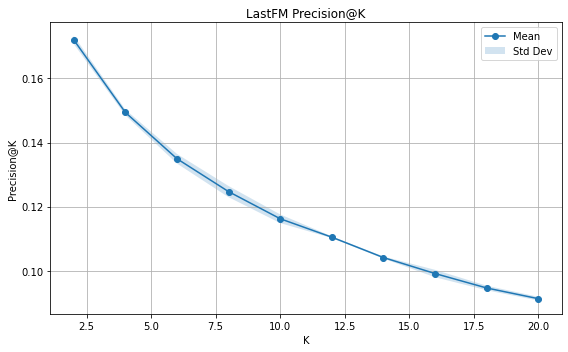

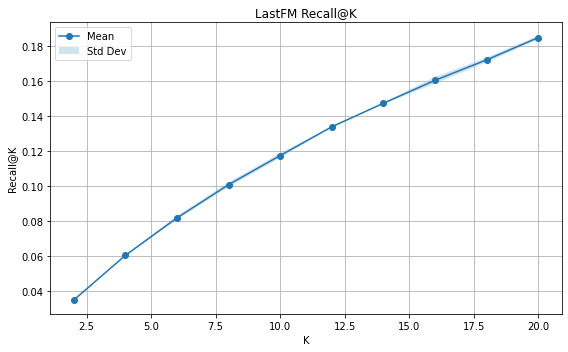

In [69]:
# ---------------- K ----------------
k, p, p_std, r, r_std = experiment_k(train_matrix, test_dict)

plot_mean_std(k, p, p_std, "K", "Precision@K",
        f"LastFM Precision@K", f"LastFM_precision_k.png")

plot_mean_std(k, r, r_std, "K", "Recall@K",
        f"LastFM Recall@K", f"LastFM_recall_k.png")

In [78]:
print("\n====================")
print("Running experiments on MovieLens")
print("====================")

movielens = load_movielens(MOVIELENS_PATH)

print(movielens.head())

train_df, test_df = train_test_split_userwise(movielens)
full_df = pd.concat([train_df, test_df])

matrix, user_map, item_map = create_matrix(full_df)

train_rows = train_df.user.map(user_map)
train_cols = train_df.item.map(item_map)

train_matrix = sp.csr_matrix(
    (np.ones(len(train_df)), (train_rows, train_cols)),
    shape=matrix.shape
)

test_dict = build_test_dict(test_df, user_map, item_map)


Running experiments on MovieLens
   user  item  value
0     1  1193      1
1     1   661      1
2     1   914      1
3     1  3408      1
4     1  2355      1


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

F=100 | P=0.2241±0.0010 | R=0.1060±0.0009
F=10 | P=0.1997±0.0015 | R=0.0834±0.0011
F=20 | P=0.2204±0.0017 | R=0.0982±0.0009
F=30 | P=0.2251±0.0015 | R=0.1030±0.0008
F=40 | P=0.2274±0.0011 | R=0.1049±0.0007
F=50 | P=0.2260±0.0014 | R=0.1051±0.0008
F=60 | P=0.2255±0.0014 | R=0.1056±0.0008
F=70 | P=0.2246±0.0014 | R=0.1053±0.0010
F=80 | P=0.2240±0.0012 | R=0.1055±0.0005
F=90 | P=0.2236±0.0014 | R=0.1055±0.0009
F=100 | P=0.2241±0.0010 | R=0.1060±0.0009


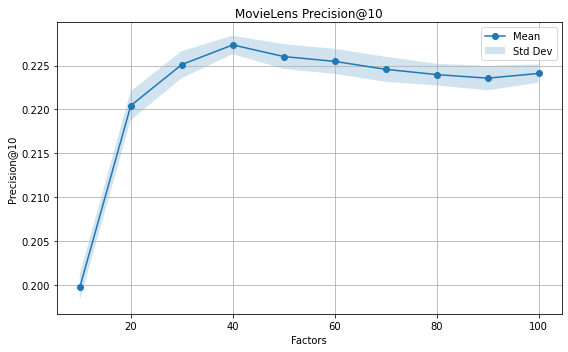

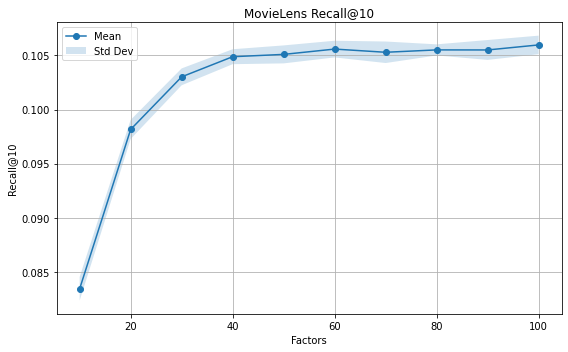

In [79]:
# ---------------- FACTORS ----------------
f, p, p_std, r, r_std = experiment_factors(train_matrix, test_dict)

plot_mean_std(f, p, p_std, "Factors", "Precision@10",
        f"MovieLens Precision@10", f"MovieLens_precision_factors.png")
plot_mean_std(f, r, r_std, "Factors", "Recall@10",
        f"MovieLens Recall@10", f"MovieLens_recall_factors.png")

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

K=20 | P=0.1775±0.0002 | R=0.1580±0.0007
K=2 | P=0.2527±0.0048 | R=0.0247±0.0006
K=4 | P=0.2370±0.0007 | R=0.0457±0.0003
K=6 | P=0.2235±0.0006 | R=0.0633±0.0002
K=8 | P=0.2146±0.0013 | R=0.0807±0.0008
K=10 | P=0.2053±0.0004 | R=0.0948±0.0003
K=12 | P=0.1984±0.0002 | R=0.1092±0.0001
K=14 | P=0.1922±0.0009 | R=0.1226±0.0009
K=16 | P=0.1874±0.0007 | R=0.1353±0.0003
K=18 | P=0.1833±0.0003 | R=0.1483±0.0001
K=20 | P=0.1775±0.0002 | R=0.1580±0.0007


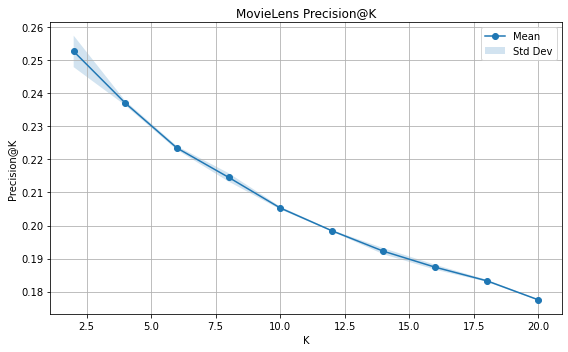

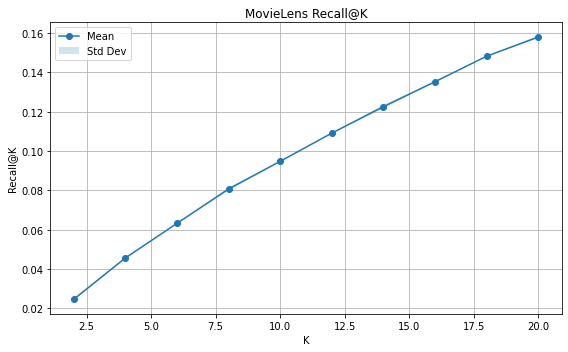

In [80]:
# ---------------- K ----------------
k, p, p_std, r, r_std = experiment_k(train_matrix, test_dict)

plot_mean_std(k, p, p_std, "K", "Precision@K",
        f"MovieLens Precision@K", f"MovieLens_precision_k.png")
plot_mean_std(k, r, r_std, "K", "Recall@K",
        f"MovieLens Recall@K", f"MovieLens_recall_k.png")